### **추가분석 4: 사고유형 및 법규위반 심화 분석 + 카이제곱 검정**

#### 규제 전후 법규위반 유형의 구성비가 통계적으로 달라졌는지 카이제곱 독립성 검정으로 확인합니다.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'data' / 'data-preprocessing').exists() and (base / 'data' / 'original-datasets').exists():
            return base

        nested = base / 'seoul-pm-safety-analysis'
        if (nested / 'data' / 'data-preprocessing').exists() and (nested / 'data' / 'original-datasets').exists():
            return nested

    raise FileNotFoundError('GitHub 저장소 루트(seoul-pm-safety-analysis)를 찾을 수 없습니다.')


PROJECT_ROOT = find_project_root()
DATA_PREP_ROOT = PROJECT_ROOT / 'data' / 'data-preprocessing'
ORIGINAL_DATA_ROOT = PROJECT_ROOT / 'data' / 'original-datasets'
print('PROJECT_ROOT:', PROJECT_ROOT)


In [6]:
pm_unit = pd.read_csv(DATA_PREP_ROOT / '서울시 PM 교통사고 현황' / '서울시_PM_교통사고_사고단위.csv', encoding='utf-8')
pm_unit['연월_dt'] = pd.to_datetime(pm_unit['연월'] + '-01')
pm_unit['규제구분'] = np.where(pm_unit['연월_dt'] >= pd.Timestamp('2021-07-01'), '규제후', '규제전')

def composition_change(df, col):
    counts = df.groupby(['규제구분', col]).size().rename('사고건수').reset_index()
    counts['비율(%)'] = counts['사고건수'] / counts.groupby('규제구분')['사고건수'].transform('sum') * 100
    pivot = counts.pivot(index=col, columns='규제구분', values=['사고건수', '비율(%)']).fillna(0)
    pivot.columns = [f'{a}_{b}' for a, b in pivot.columns]
    pivot = pivot.reset_index().rename(columns={col: '분류값'})
    pivot['분석항목'] = col
    pivot['비율증감(pp)'] = pivot.get('비율(%)_규제후', 0) - pivot.get('비율(%)_규제전', 0)
    return pivot

cols = ['사고유형_대분류', '법규위반', '도로형태_대분류', 'PM_역할', '주야']
detail = pd.concat([composition_change(pm_unit, c) for c in cols], ignore_index=True)
display(detail[detail['분석항목'] == '법규위반'].sort_values('사고건수_규제후', ascending=False).head(10))


,분류값,사고건수_규제전,사고건수_규제후,비율(%)_규제전,비율(%)_규제후,분석항목,비율증감(pp)
9,안전운전불이행,643.0,1266.0,57.513417,56.822262,법규위반,-0.691155
5,기타,209.0,442.0,18.694097,19.838420,법규위반,1.144324
7,신호위반,130.0,289.0,11.627907,12.971275,법규위반,1.343368
10,중앙선침범,45.0,70.0,4.025045,3.141831,법규위반,-0.883213
8,안전거리미확보,29.0,62.0,2.593918,2.782765,법규위반,0.188847
6,보행자보호의무위반,15.0,58.0,1.341682,2.603232,법규위반,1.261550
4,교차로운행방법위반,45.0,41.0,4.025045,1.840215,법규위반,-2.184829
3,과속,2.0,0.0,0.178891,0.000000,법규위반,-0.178891


In [7]:
chi_rows = []
for col in cols:
    contingency = pd.crosstab(pm_unit['규제구분'], pm_unit[col])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    chi_rows.append({
        '분석항목': col,
        'chi2': chi2,
        'dof': dof,
        'p-value': p_value,
        '유의여부(p<0.05)': '유의' if p_value < 0.05 else '유의하지 않음'
    })

chi_result = pd.DataFrame(chi_rows)
display(chi_result)


,분석항목,chi2,dof,p-value,유의여부(p<0.05)
0,사고유형_대분류,19.158620,2,6.914464e-05,유의
1,법규위반,26.665586,7,3.827599e-04,유의
2,도로형태_대분류,12.349911,4,1.493035e-02,유의
3,PM_역할,40.487432,3,8.398869e-09,유의
4,주야,6.680320,1,9.748310e-03,유의


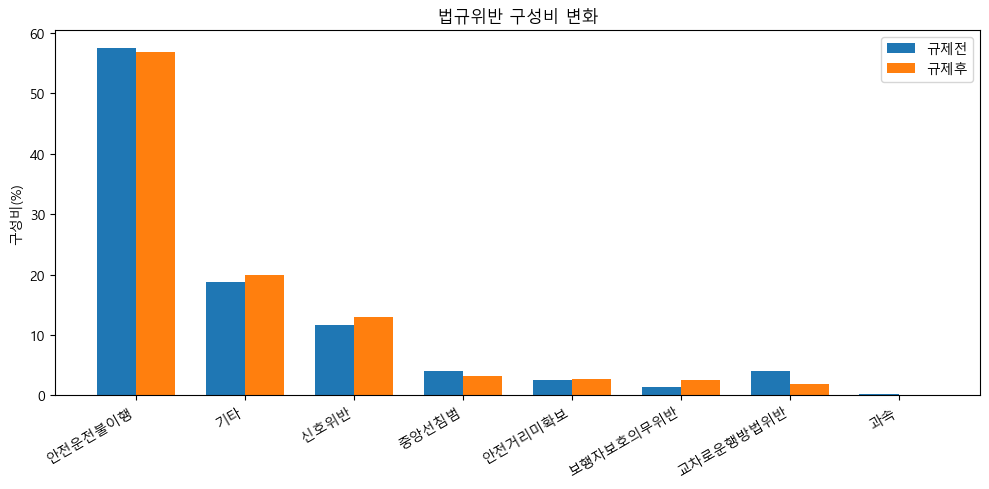

In [8]:
law = detail[detail['분석항목'] == '법규위반'].sort_values('사고건수_규제후', ascending=False).head(8)
plt.figure(figsize=(10, 5))
x = np.arange(len(law))
plt.bar(x - 0.18, law['비율(%)_규제전'], width=0.36, label='규제전')
plt.bar(x + 0.18, law['비율(%)_규제후'], width=0.36, label='규제후')
plt.xticks(x, law['분류값'], rotation=30, ha='right')
plt.ylabel('구성비(%)')
plt.title('법규위반 구성비 변화')
plt.legend()
plt.tight_layout()
plt.show()


#### 카이제곱 검정 결과 요약

| 분석항목 | chi2 | dof | p-value | 유의여부(p<0.05) |
| --- | --- | --- | --- | --- |
| 사고유형_대분류 | 19.1586 | 2 | 0.0001 | 유의 |
| 법규위반 | 26.6656 | 7 | 0.0004 | 유의 |
| 도로형태_대분류 | 12.3499 | 4 | 0.0149 | 유의 |
| PM_역할 | 40.4874 | 3 | 0.0000 | 유의 |
| 주야 | 6.8713 | 1 | 0.0088 | 유의 |

**법규위반 상위 항목**

| 분류값 | 사고건수_규제전 | 사고건수_규제후 | 비율(%)_규제전 | 비율(%)_규제후 | 비율증감(pp) |
| --- | --- | --- | --- | --- | --- |
| 안전운전불이행 | 643.0000 | 1266.0000 | 57.5134 | 56.8223 | -0.6912 |
| 기타 | 209.0000 | 442.0000 | 18.6941 | 19.8384 | 1.1443 |
| 신호위반 | 130.0000 | 289.0000 | 11.6279 | 12.9713 | 1.3434 |
| 중앙선침범 | 45.0000 | 70.0000 | 4.0250 | 3.1418 | -0.8832 |
| 안전거리미확보 | 29.0000 | 62.0000 | 2.5939 | 2.7828 | 0.1888 |
| 교차로운행방법위반 | 45.0000 | 41.0000 | 4.0250 | 1.8402 | -2.1848 |
| 보행자보호의무위반 | 15.0000 | 58.0000 | 1.3417 | 2.6032 | 1.2616 |
| 과속 | 2.0000 | 0.0000 | 0.1789 | 0.0000 | -0.1789 |

- `법규위반` 항목의 p-value는 0.0004로 0.05보다 작아, 규제 전후 위반 유형 분포는 통계적으로 유의하게 달라진 것으로 볼 수 있습니다.
- 따라서 단순히 `양상이 비슷하다`고 쓰기보다는, 어떤 위반 유형의 구성비가 증가/감소했는지 표와 함께 해석하는 방향이 적절합니다.